In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize']= (12,6)

In [ ]:
# Load optimized data from pickle file (data types preserved)
import pickle

with open('../../data/train_optimized.pkl', 'rb') as f:
    df = pickle.load(f)

print("="*80)
print(f"Dataset shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

In [ ]:
df = df.set_index('TransactionID') 

df.head()

In [ ]:
# List categorical columns (object and category types)
categorical_cols = [col for col in df.columns if df[col].dtype in ['object', 'category']]

# High cardinality categorical columns (>50 unique values)
categorical_but_high_cardinality = [col for col in categorical_cols 
                                    if df[col].nunique() > 50]

# Low cardinality categorical columns (<=50 unique values) - SEPARATED
categorical_cols_clean = [col for col in categorical_cols 
                          if col not in categorical_but_high_cardinality]

# All numeric columns
numeric_cols = [col for col in df.columns 
                if df[col].dtype in ['int64', 'float64', 'Int32', 'Int8', 'Int16']]

# Numeric columns that behave like categorical (<20 unique values)
numeric_but_categorical = [col for col in numeric_cols 
                          if df[col].nunique() < 20 
                          and col not in ['isFraud', 'TransactionID']]

# Pure numeric columns (continuous) - SEPARATED
numeric_cols_clean = [col for col in numeric_cols 
                      if col not in numeric_but_categorical 
                      and col not in ['isFraud', 'TransactionID']]

print("="*80)
print("COLUMN CLASSIFICATION")
print("="*80)

print(f"\n📌 CATEGORICAL COLUMNS:")
print(f"   - Total Categorical: {len(categorical_cols)}")
print(f"   - Low Cardinality (<=50 unique): {len(categorical_cols_clean)}")
print(f"   - High Cardinality (>50 unique): {len(categorical_but_high_cardinality)}")

print(f"\n📌 NUMERIC COLUMNS:")
print(f"   - Total Numeric: {len(numeric_cols)}")
print(f"   - Continuous (>=20 unique): {len(numeric_cols_clean)}")
print(f"   - Categorical-like (<20 unique): {len(numeric_but_categorical)}")

print(f"\n📌 TOTAL: {len(df.columns)} columns")
print("="*80)

# Display the column lists
print(f"\nCategorical (Low Cardinality): {categorical_cols_clean}")
print(f"\nCategorical (High Cardinality): {categorical_but_high_cardinality}")
print(f"\nNumeric (Categorical-like): {numeric_but_categorical}")

## 1. Target Distribution (Fraud Rate Analysis)

In [ ]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
fraud_counts = df['isFraud'].value_counts()
axes[0].bar(['Not Fraud (0)', 'Fraud (1)'], fraud_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Fraud Distribution (Count)', fontsize=14)
axes[0].set_ylabel('Count')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Percentage pie chart
axes[1].pie(fraud_counts.values, labels=['Not Fraud', 'Fraud'], autopct='%1.2f%%', 
            colors=['#2ecc71', '#e74c3c'], explode=[0, 0.1])
axes[1].set_title('Fraud Distribution (%)', fontsize=14)

plt.tight_layout()
plt.show()

print(f"Fraud Rate: {df['isFraud'].mean()*100:.2f}%")
print(f"Class Imbalance Ratio: 1:{int((1-df['isFraud'].mean())/df['isFraud'].mean())}")

## 2. Feature Groups Overview (IEEE Dataset Structure)

In [ ]:
# Group columns by their prefix/category
feature_groups = {
    'Transaction Core': ['TransactionDT', 'TransactionAmt', 'ProductCD', 'isFraud'],
    'Card Info': [col for col in df.columns if col.startswith('card')],
    'Address': [col for col in df.columns if col.startswith('addr')],
    'Email Domain': [col for col in df.columns if 'emaildomain' in col.lower()],
    'M Features (Match)': [col for col in df.columns if col.startswith('M')],
    'C Features (Count)': [col for col in df.columns if col.startswith('C') and col[1:].isdigit()],
    'D Features (Timedelta)': [col for col in df.columns if col.startswith('D') and col[1:].isdigit()],
    'V Features (Vesta)': [col for col in df.columns if col.startswith('V')],
    'ID Features': [col for col in df.columns if col.startswith('id_')],
    'Device Info': [col for col in df.columns if 'device' in col.lower()],
}

print("="*80)
print("IEEE FRAUD DETECTION - FEATURE GROUPS")
print("="*80)

total = 0
group_sizes = {}
for group, cols in feature_groups.items():
    existing_cols = [c for c in cols if c in df.columns]
    group_sizes[group] = len(existing_cols)
    total += len(existing_cols)
    print(f"{group:25s}: {len(existing_cols):3d} columns")

print("="*80)
print(f"{'TOTAL':25s}: {total:3d} columns")

# Visualize group sizes
plt.figure(figsize=(12, 6))
groups = list(group_sizes.keys())
sizes = list(group_sizes.values())
colors = plt.cm.Set3(np.linspace(0, 1, len(groups)))

bars = plt.barh(groups, sizes, color=colors)
plt.xlabel('Number of Features')
plt.title('Feature Distribution by Group')

for bar, size in zip(bars, sizes):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
             f'{size}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Missing Values Analysis

In [ ]:
# Missing values by feature group
missing_by_group = {}

for group, cols in feature_groups.items():
    existing_cols = [c for c in cols if c in df.columns]
    if existing_cols:
        missing_pct = df[existing_cols].isnull().mean().mean() * 100
        missing_by_group[group] = missing_pct

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Missing by group
groups = list(missing_by_group.keys())
missing_pcts = list(missing_by_group.values())
colors = ['#e74c3c' if p > 50 else '#f39c12' if p > 20 else '#2ecc71' for p in missing_pcts]

bars = axes[0].barh(groups, missing_pcts, color=colors)
axes[0].set_xlabel('Missing Rate (%)')
axes[0].set_title('Missing Values by Feature Group')
axes[0].axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50% threshold')

for bar, pct in zip(bars, missing_pcts):
    axes[0].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
                 f'{pct:.1f}%', va='center')

# Top 20 columns with most missing
missing_cols = df.isnull().mean().sort_values(ascending=False).head(20) * 100
axes[1].barh(missing_cols.index, missing_cols.values, color='#e74c3c')
axes[1].set_xlabel('Missing Rate (%)')
axes[1].set_title('Top 20 Columns with Most Missing Values')

plt.tight_layout()
plt.show()

# Summary
print(f"\nColumns with >50% missing: {(df.isnull().mean() > 0.5).sum()}")
print(f"Columns with no missing: {(df.isnull().mean() == 0).sum()}")
print(f"Total missing cells: {df.isnull().sum().sum():,} ({df.isnull().mean().mean()*100:.1f}%)")

## 4. Transaction Amount Analysis

In [ ]:
# Transaction Amount distribution by fraud status
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution (log scale)
for fraud_val, color, label in [(0, '#2ecc71', 'Not Fraud'), (1, '#e74c3c', 'Fraud')]:
    data = df[df['isFraud'] == fraud_val]['TransactionAmt']
    axes[0, 0].hist(np.log1p(data), bins=50, alpha=0.6, color=color, label=label)
axes[0, 0].set_xlabel('Log(TransactionAmt + 1)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Transaction Amount Distribution (Log Scale)')
axes[0, 0].legend()

# Box plot by fraud
df.boxplot(column='TransactionAmt', by='isFraud', ax=axes[0, 1])
axes[0, 1].set_title('Transaction Amount by Fraud Status')
axes[0, 1].set_xlabel('isFraud')
axes[0, 1].set_ylabel('TransactionAmt')
plt.suptitle('')

# Summary statistics
fraud_amt = df[df['isFraud'] == 1]['TransactionAmt']
not_fraud_amt = df[df['isFraud'] == 0]['TransactionAmt']

stats_data = {
    'Metric': ['Mean', 'Median', 'Std', 'Min', 'Max', '25%', '75%'],
    'Not Fraud': [not_fraud_amt.mean(), not_fraud_amt.median(), not_fraud_amt.std(), 
                  not_fraud_amt.min(), not_fraud_amt.max(), not_fraud_amt.quantile(0.25), not_fraud_amt.quantile(0.75)],
    'Fraud': [fraud_amt.mean(), fraud_amt.median(), fraud_amt.std(),
              fraud_amt.min(), fraud_amt.max(), fraud_amt.quantile(0.25), fraud_amt.quantile(0.75)]
}

# Amount ranges fraud rate
bins = [0, 50, 100, 200, 500, 1000, 5000, 10000, float('inf')]
labels = ['0-50', '50-100', '100-200', '200-500', '500-1K', '1K-5K', '5K-10K', '10K+']
df['amt_bin'] = pd.cut(df['TransactionAmt'], bins=bins, labels=labels)

fraud_by_amt = df.groupby('amt_bin')['isFraud'].agg(['mean', 'count'])
fraud_by_amt['mean'] = fraud_by_amt['mean'] * 100

axes[1, 0].bar(fraud_by_amt.index.astype(str), fraud_by_amt['mean'], color='#3498db')
axes[1, 0].set_xlabel('Transaction Amount Range')
axes[1, 0].set_ylabel('Fraud Rate (%)')
axes[1, 0].set_title('Fraud Rate by Amount Range')
axes[1, 0].tick_params(axis='x', rotation=45)

# Transaction count by range
axes[1, 1].bar(fraud_by_amt.index.astype(str), fraud_by_amt['count'], color='#9b59b6')
axes[1, 1].set_xlabel('Transaction Amount Range')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Transaction Count by Amount Range')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Clean up temp column
df = df.drop('amt_bin', axis=1)

# Print stats
print("\nTransaction Amount Statistics:")
print(pd.DataFrame(stats_data).to_string(index=False))

## 5. Categorical Features - Fraud Rate Analysis

In [ ]:
# Key categorical features fraud analysis
key_cats = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'DeviceType']
existing_cats = [c for c in key_cats if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, col in enumerate(existing_cats):
    # Calculate fraud rate per category
    fraud_rate = df.groupby(col)['isFraud'].agg(['mean', 'count']).reset_index()
    fraud_rate['mean'] = fraud_rate['mean'] * 100
    fraud_rate = fraud_rate.sort_values('mean', ascending=False).head(10)
    
    # Plot
    colors = plt.cm.RdYlGn_r(fraud_rate['mean'] / fraud_rate['mean'].max())
    bars = axes[idx].barh(fraud_rate[col].astype(str), fraud_rate['mean'], color=colors)
    axes[idx].set_xlabel('Fraud Rate (%)')
    axes[idx].set_title(f'{col} - Fraud Rate by Category')
    
    # Add count labels
    for bar, count in zip(bars, fraud_rate['count']):
        axes[idx].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
                      f'n={count:,}', va='center', fontsize=8)

# Card features (card1-card6)
card_cols = [c for c in df.columns if c.startswith('card') and c in ['card1', 'card2', 'card3', 'card5']]
card_fraud_rates = {}

for col in card_cols:
    # Top 5 fraud rate categories for each card
    top_fraud = df.groupby(col)['isFraud'].mean().nlargest(5).mean() * 100
    card_fraud_rates[col] = top_fraud

axes[5].bar(card_fraud_rates.keys(), card_fraud_rates.values(), color='#e74c3c')
axes[5].set_ylabel('Avg Fraud Rate of Top 5 Categories (%)')
axes[5].set_title('Card Features - Fraud Potential')

plt.tight_layout()
plt.show()

## 6. Time Analysis (TransactionDT)

In [ ]:
# TransactionDT is seconds from a reference datetime
# Extract time features
df['hour'] = (df['TransactionDT'] // 3600) % 24
df['day'] = (df['TransactionDT'] // (3600 * 24)) % 7
df['week'] = df['TransactionDT'] // (3600 * 24 * 7)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Fraud rate by hour
hourly_fraud = df.groupby('hour')['isFraud'].mean() * 100
axes[0, 0].plot(hourly_fraud.index, hourly_fraud.values, marker='o', color='#e74c3c', linewidth=2)
axes[0, 0].fill_between(hourly_fraud.index, hourly_fraud.values, alpha=0.3, color='#e74c3c')
axes[0, 0].set_xlabel('Hour of Day')
axes[0, 0].set_ylabel('Fraud Rate (%)')
axes[0, 0].set_title('Fraud Rate by Hour of Day')
axes[0, 0].set_xticks(range(0, 24, 2))
axes[0, 0].grid(True, alpha=0.3)

# Transaction volume by hour
hourly_count = df.groupby('hour').size()
axes[0, 1].bar(hourly_count.index, hourly_count.values, color='#3498db', alpha=0.7)
axes[0, 1].set_xlabel('Hour of Day')
axes[0, 1].set_ylabel('Transaction Count')
axes[0, 1].set_title('Transaction Volume by Hour')

# Fraud rate by day of week
daily_fraud = df.groupby('day')['isFraud'].mean() * 100
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1, 0].bar(range(7), daily_fraud.values, color='#9b59b6')
axes[1, 0].set_xlabel('Day of Week')
axes[1, 0].set_ylabel('Fraud Rate (%)')
axes[1, 0].set_title('Fraud Rate by Day of Week')
axes[1, 0].set_xticks(range(7))
axes[1, 0].set_xticklabels(days)

# Fraud over time (weeks)
weekly_fraud = df.groupby('week')['isFraud'].mean() * 100
axes[1, 1].plot(weekly_fraud.index, weekly_fraud.values, color='#e74c3c', linewidth=2)
axes[1, 1].set_xlabel('Week Number')
axes[1, 1].set_ylabel('Fraud Rate (%)')
axes[1, 1].set_title('Fraud Rate Over Time (Weekly)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Clean up temp columns
df = df.drop(['hour', 'day', 'week'], axis=1)

print(f"\nPeak fraud hour: {hourly_fraud.idxmax()}:00 ({hourly_fraud.max():.2f}%)")
print(f"Lowest fraud hour: {hourly_fraud.idxmin()}:00 ({hourly_fraud.min():.2f}%)")

## 7. V Features Correlation Analysis (Vesta Engineered)

In [ ]:
# V features are Vesta-engineered features (V1-V339)
v_cols = [col for col in df.columns if col.startswith('V')]
print(f"Total V features: {len(v_cols)}")

# Correlation with target
v_target_corr = df[v_cols + ['isFraud']].corr()['isFraud'].drop('isFraud').abs().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 20 V features correlated with fraud
top_v = v_target_corr.head(20)
axes[0].barh(top_v.index, top_v.values, color='#e74c3c')
axes[0].set_xlabel('Absolute Correlation with isFraud')
axes[0].set_title('Top 20 V Features Correlated with Fraud')
axes[0].invert_yaxis()

# V features correlation distribution
axes[1].hist(v_target_corr.values, bins=50, color='#3498db', edgecolor='white')
axes[1].set_xlabel('Absolute Correlation')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of V Feature Correlations with Fraud')
axes[1].axvline(x=0.1, color='red', linestyle='--', label='0.1 threshold')
axes[1].legend()

plt.tight_layout()
plt.show()

# Group V features by correlation strength
high_corr_v = v_target_corr[v_target_corr > 0.1].index.tolist()
med_corr_v = v_target_corr[(v_target_corr > 0.05) & (v_target_corr <= 0.1)].index.tolist()
low_corr_v = v_target_corr[v_target_corr <= 0.05].index.tolist()

print(f"\nV Features by Correlation Strength:")
print(f"  High (>0.1): {len(high_corr_v)} features")
print(f"  Medium (0.05-0.1): {len(med_corr_v)} features")
print(f"  Low (<0.05): {len(low_corr_v)} features")
print(f"\nTop 5 V features: {list(top_v.head(5).index)}")

## 8. Identity Features Analysis

In [ ]:
# Identity features (id_01 - id_38)
id_cols = [col for col in df.columns if col.startswith('id_')]
print(f"Total ID features: {len(id_cols)}")

# Check which ones are numeric vs categorical
id_numeric = [col for col in id_cols if df[col].dtype in ['int64', 'float64', 'Int8', 'Int16', 'Int32']]
id_categorical = [col for col in id_cols if col not in id_numeric]

print(f"Numeric ID features: {len(id_numeric)}")
print(f"Categorical ID features: {len(id_categorical)}")

# Correlation of numeric ID features with fraud
if id_numeric:
    id_corr = df[id_numeric + ['isFraud']].corr()['isFraud'].drop('isFraud').abs().sort_values(ascending=False)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Correlation
    axes[0].barh(id_corr.index, id_corr.values, color='#9b59b6')
    axes[0].set_xlabel('Absolute Correlation with isFraud')
    axes[0].set_title('ID Features Correlation with Fraud')
    axes[0].invert_yaxis()
    
    # Missing rate
    id_missing = df[id_cols].isnull().mean().sort_values(ascending=False) * 100
    axes[1].barh(id_missing.index, id_missing.values, color='#e74c3c')
    axes[1].set_xlabel('Missing Rate (%)')
    axes[1].set_title('ID Features Missing Rate')
    axes[1].invert_yaxis()
    
    plt.tight_layout()
    plt.show()

# Device analysis
if 'DeviceType' in df.columns:
    print("\nDevice Type Analysis:")
    device_fraud = df.groupby('DeviceType')['isFraud'].agg(['mean', 'count'])
    device_fraud['mean'] = device_fraud['mean'] * 100
    print(device_fraud.to_string())

## 9. Feature Importance Summary & Recommendations

In [ ]:
# Overall correlation analysis - Top features
numeric_df = df.select_dtypes(include=[np.number])
all_corr = numeric_df.corr()['isFraud'].drop('isFraud').abs().sort_values(ascending=False)

# Top 30 features
top_30 = all_corr.head(30)

plt.figure(figsize=(12, 10))
colors = ['#e74c3c' if 'V' in idx else '#3498db' if 'C' in idx else '#2ecc71' if 'D' in idx else '#9b59b6' for idx in top_30.index]
plt.barh(top_30.index, top_30.values, color=colors)
plt.xlabel('Absolute Correlation with isFraud')
plt.title('Top 30 Features Correlated with Fraud')
plt.gca().invert_yaxis()

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='V Features'),
                   Patch(facecolor='#3498db', label='C Features'),
                   Patch(facecolor='#2ecc71', label='D Features'),
                   Patch(facecolor='#9b59b6', label='Other')]
plt.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

# Summary
print("="*80)
print("EDA SUMMARY & RECOMMENDATIONS")
print("="*80)
print(f"""
📊 DATASET OVERVIEW:
   - Total Features: {len(df.columns)}
   - Fraud Rate: {df['isFraud'].mean()*100:.2f}% (Highly Imbalanced)
   
🔑 KEY FINDINGS:
   1. V features (Vesta) are most predictive - {len([c for c in top_30.index if 'V' in c])} in top 30
   2. C features (Count) show strong fraud signals
   3. Time features reveal fraud patterns by hour
   4. High missing rate in identity features (~40%)
   
⚡ RECOMMENDATIONS FOR MODELING:
   1. Use class_weight='balanced' or SMOTE for imbalance
   2. Focus on V features for feature selection
   3. Create time-based features (hour, day_of_week)
   4. Handle missing values carefully (especially identity)
   5. Use TimeSeriesSplit for validation (time-based data)
   
🎯 POTENTIAL NEW FEATURES:
   - Transaction amount bins
   - Hour of transaction
   - Email domain matching (P vs R)
   - Card info aggregations
""")
print("="*80)

## 10. TransactionAmt Decimal Analysis (Currency Detection)

In [ ]:
# =============================================================================
# TransactionAmt - Ondalık Kısım Analizi (Fraud Detection Signal)
# =============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Ondalık kısmı ayır
df['amt_decimal'] = df['TransactionAmt'] % 1  # Ondalık kısım (0.00 - 0.99)
df['amt_integer'] = df['TransactionAmt'] // 1  # Tam sayı kısmı
df['is_round'] = (df['amt_decimal'] == 0).astype(int)  # Yuvarlak mı?
df['cents'] = (df['amt_decimal'] * 100).round().astype(int)  # Cent değeri

fraud_df = df[df['isFraud'] == 1]
nofraud_df = df[df['isFraud'] == 0]

# 1. Ondalık kısım dağılımı (Histogram)
ax1 = axes[0, 0]
ax1.hist(nofraud_df['amt_decimal'], bins=100, alpha=0.6, color='#2ecc71', label='No Fraud', density=True)
ax1.hist(fraud_df['amt_decimal'], bins=100, alpha=0.6, color='#e74c3c', label='Fraud', density=True)
ax1.set_xlabel('Ondalık Kısım (0.00 - 0.99)')
ax1.set_ylabel('Density')
ax1.set_title('TransactionAmt Ondalık Kısım Dağılımı\nFraud vs No Fraud')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Yuvarlak Sayı Oranı (0.00 ile biten)
ax2 = axes[0, 1]
round_fraud_rate = df.groupby('is_round')['isFraud'].mean() * 100
colors = ['#3498db', '#e74c3c']
bars = ax2.bar(['Ondalıklı\n(x.xx)', 'Yuvarlak\n(x.00)'], round_fraud_rate.values, color=colors)
ax2.set_ylabel('Fraud Rate (%)')
ax2.set_title('Yuvarlak vs Ondalıklı Tutarların\nFraud Oranı')
for bar, val in zip(bars, round_fraud_rate.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f'{val:.2f}%', ha='center', fontweight='bold')
ax2.grid(True, alpha=0.3)

# 3. Popüler Cent Değerleri
ax3 = axes[0, 2]
cent_counts_fraud = fraud_df['cents'].value_counts().head(15)
cent_counts_nofraud = nofraud_df['cents'].value_counts().head(15)

all_top_cents = list(set(cent_counts_fraud.index.tolist() + cent_counts_nofraud.index.tolist()))[:15]
x = np.arange(len(all_top_cents))
width = 0.35

fraud_vals = [fraud_df[fraud_df['cents'] == c].shape[0] / len(fraud_df) * 100 for c in all_top_cents]
nofraud_vals = [nofraud_df[nofraud_df['cents'] == c].shape[0] / len(nofraud_df) * 100 for c in all_top_cents]

ax3.bar(x - width/2, nofraud_vals, width, label='No Fraud', color='#2ecc71')
ax3.bar(x + width/2, fraud_vals, width, label='Fraud', color='#e74c3c')
ax3.set_xlabel('Cent Değeri')
ax3.set_ylabel('Oran (%)')
ax3.set_title('En Popüler Cent Değerleri')
ax3.set_xticks(x)
ax3.set_xticklabels([f'.{c:02d}' for c in all_top_cents], rotation=45)
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Cent değerine göre Fraud Rate
ax4 = axes[1, 0]
cent_fraud_rate = df.groupby('cents')['isFraud'].agg(['mean', 'count'])
cent_fraud_rate = cent_fraud_rate[cent_fraud_rate['count'] > 100]
cent_fraud_rate['mean'] = cent_fraud_rate['mean'] * 100
cent_fraud_rate_sorted = cent_fraud_rate.sort_values('mean', ascending=False).head(20)

colors = plt.cm.Reds(cent_fraud_rate_sorted['mean'] / cent_fraud_rate_sorted['mean'].max())
ax4.barh([f'.{c:02d}' for c in cent_fraud_rate_sorted.index], 
         cent_fraud_rate_sorted['mean'], color=colors)
ax4.set_xlabel('Fraud Rate (%)')
ax4.set_ylabel('Cent Değeri')
ax4.set_title('En Yüksek Fraud Oranına Sahip\nCent Değerleri (min 100 işlem)')
ax4.grid(True, alpha=0.3)

# 5. Ondalık kısım KDE karşılaştırması
ax5 = axes[1, 1]
from scipy import stats
x_range = np.linspace(0, 1, 500)
nofraud_kde = stats.gaussian_kde(nofraud_df['amt_decimal'])
fraud_kde = stats.gaussian_kde(fraud_df['amt_decimal'])

ax5.fill_between(x_range, nofraud_kde(x_range), alpha=0.5, color='#2ecc71', label='No Fraud')
ax5.fill_between(x_range, fraud_kde(x_range), alpha=0.5, color='#e74c3c', label='Fraud')
ax5.plot(x_range, nofraud_kde(x_range), color='#27ae60', linewidth=2)
ax5.plot(x_range, fraud_kde(x_range), color='#c0392b', linewidth=2)
ax5.set_xlabel('Ondalık Kısım')
ax5.set_ylabel('Density')
ax5.set_title('Ondalık Kısım KDE Dağılımı')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. Özel Ondalık Grupları
ax6 = axes[1, 2]
def categorize_decimal(x):
    if x == 0:
        return '0: Yuvarlak (.00)'
    elif x == 0.5:
        return '1: Yarım (.50)'
    elif x in [0.25, 0.75]:
        return '2: Çeyrek (.25/.75)'
    elif x == round(x, 1):
        return '3: Tek ondalık (.x0)'
    elif x == 0.99:
        return '4: 99 cent (.99)'
    else:
        return '5: Diğer'

df['decimal_category'] = df['amt_decimal'].apply(categorize_decimal)
cat_fraud = df.groupby('decimal_category')['isFraud'].agg(['mean', 'count']).sort_index()
cat_fraud['mean'] = cat_fraud['mean'] * 100

colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(cat_fraud)))
bars = ax6.barh(cat_fraud.index, cat_fraud['mean'], color=colors)
ax6.set_xlabel('Fraud Rate (%)')
ax6.set_title('Ondalık Kategorilerine Göre Fraud Oranı')
for bar, (idx, row) in zip(bars, cat_fraud.iterrows()):
    ax6.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
             f'{row["mean"]:.2f}% (n={row["count"]:,})', va='center', fontsize=9)
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# İstatistiksel Özet
print("="*80)
print("TransactionAmt ONDALIK KISIM ANALİZİ - ÖZET")
print("="*80)

# Yuvarlak sayı analizi
round_stats = df.groupby('is_round').agg({
    'isFraud': ['sum', 'count', 'mean'],
    'TransactionAmt': 'mean'
})
round_stats.columns = ['Fraud_Count', 'Total_Count', 'Fraud_Rate', 'Avg_Amount']
round_stats.index = ['Ondalıklı', 'Yuvarlak']
round_stats['Fraud_Rate'] = round_stats['Fraud_Rate'] * 100

print("\n📊 YUVARLAK vs ONDALIKLI TUTAR:")
print(round_stats.to_string())

# En riskli cent değerleri
print("\n📊 EN RİSKLİ CENT DEĞERLERİ (min 500 işlem):")
cent_risk = df.groupby('cents')['isFraud'].agg(['mean', 'count'])
cent_risk = cent_risk[cent_risk['count'] > 500].sort_values('mean', ascending=False).head(10)
cent_risk['mean'] = cent_risk['mean'] * 100
for cent, row in cent_risk.iterrows():
    print(f"   .{cent:02d} → Fraud Rate: {row['mean']:.2f}% (n={row['count']:,})")

# KS Test
ks_stat, ks_pval = stats.ks_2samp(fraud_df['amt_decimal'], nofraud_df['amt_decimal'])
print(f"\n📊 Kolmogorov-Smirnov Test (Ondalık Kısım):")
print(f"   KS Statistic: {ks_stat:.4f}")
print(f"   P-value: {ks_pval:.2e}")
print(f"   Sonuç: {'Dağılımlar anlamlı şekilde FARKLI ✓' if ks_pval < 0.05 else 'Dağılımlar benzer'}")

# Temizlik
df.drop(['amt_decimal', 'amt_integer', 'is_round', 'cents', 'decimal_category'], axis=1, inplace=True)
print("="*80)

## 11. Card3 Country/Region Detection (Currency Conversion Analysis)

In [ ]:
# =============================================================================
# CARD3 - YABANCI ÜLKE TESPİTİ (USD Pattern'leri DIŞINDA kalanların yoğunluğu)
# =============================================================================
# Mantık: USD işlemleri belirli cent değerlerinde yoğunlaşır (.00, .50, .99, .95, .49, .90, .25, .75)
#         Kur dönüşümü yapan ülkelerde cent değerleri RASTGELE dağılır

# Ondalık hesapla
df['amt_decimal'] = df['TransactionAmt'] % 1
df['cents'] = (df['amt_decimal'] * 100).round().astype(int)

# USD'nin tipik cent değerleri (psikolojik fiyatlama + yuvarlak)
usd_typical_cents = [0, 25, 49, 50, 75, 90, 95, 99]

# "Rastgele" cent değerleri = USD pattern'leri dışındakiler
df['is_random_cent'] = ~df['cents'].isin(usd_typical_cents)

# card3 analizi
card3_values = df['card3'].value_counts().head(15).index.tolist()

# Her card3 için rastgele cent oranı
random_cent_analysis = []
for card_val in card3_values:
    subset = df[df['card3'] == card_val]
    random_pct = subset['is_random_cent'].mean() * 100
    fraud_rate = subset['isFraud'].mean() * 100
    avg_amt = subset['TransactionAmt'].mean()
    
    random_cent_analysis.append({
        'card3': card_val,
        'count': len(subset),
        'random_cent_pct': random_pct,
        'fraud_rate': fraud_rate,
        'avg_amt': avg_amt
    })

analysis_df = pd.DataFrame(random_cent_analysis).sort_values('random_cent_pct', ascending=False)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Random Cent Oranı (Yabancı Ülke Göstergesi)
ax1 = axes[0]
colors = ['#e74c3c' if x > 60 else '#f39c12' if x > 40 else '#2ecc71' for x in analysis_df['random_cent_pct']]
bars = ax1.barh(analysis_df['card3'].astype(str), analysis_df['random_cent_pct'], color=colors)
ax1.axvline(x=50, color='black', linestyle='--', alpha=0.7, label='%50 eşik')
ax1.set_xlabel('Rastgele Cent Oranı (%)')
ax1.set_ylabel('card3')
ax1.set_title('🌍 YABANCI ÜLKE TESPİTİ\n(Yüksek = Kur Dönüşümü Var = Non-USD)')
ax1.legend()

for bar, row in zip(bars, analysis_df.itertuples()):
    label = "🌍" if row.random_cent_pct > 60 else "❓" if row.random_cent_pct > 40 else "🇺🇸"
    ax1.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
             f'{row.random_cent_pct:.1f}% {label}', va='center', fontsize=9)

# 2. Fraud Rate vs Random Cent
ax2 = axes[1]
scatter_colors = ['#e74c3c' if x > 60 else '#f39c12' if x > 40 else '#2ecc71' for x in analysis_df['random_cent_pct']]
ax2.scatter(analysis_df['random_cent_pct'], analysis_df['fraud_rate'], 
            s=analysis_df['count']/1000, c=scatter_colors, alpha=0.7, edgecolors='black')
ax2.set_xlabel('Rastgele Cent Oranı (%) - Yabancı Ülke Göstergesi')
ax2.set_ylabel('Fraud Rate (%)')
ax2.set_title('Yabancı Ülke vs Fraud Rate\n(Daire boyutu = işlem sayısı)')
ax2.axvline(x=50, color='black', linestyle='--', alpha=0.5)

for _, row in analysis_df.iterrows():
    ax2.annotate(str(int(row['card3'])), (row['random_cent_pct'], row['fraud_rate']), 
                fontsize=8, ha='center')

# 3. İşlem Hacmi Dağılımı
ax3 = axes[2]
foreign_mask = analysis_df['random_cent_pct'] > 50
domestic = analysis_df[~foreign_mask]['count'].sum()
foreign = analysis_df[foreign_mask]['count'].sum()

ax3.pie([domestic, foreign], labels=['🇺🇸 USD (Yerli)', '🌍 Non-USD (Yabancı)'], 
        autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], explode=[0, 0.1])
ax3.set_title(f'İşlem Hacmi Dağılımı\n(Top 15 card3 değeri)')

plt.tight_layout()
plt.show()

# Detaylı Tablo
print("="*100)
print("🌍 YABANCI ÜLKE TESPİTİ - CARD3 ANALİZİ")
print("="*100)
print("Mantık: USD pattern'leri (.00, .25, .49, .50, .75, .90, .95, .99) DIŞINDA kalan cent oranı")
print("        Yüksek oran = Kur dönüşümü var = Yabancı para birimi kullanıyor")
print("="*100)

print(f"\n{'card3':>8} {'Count':>12} {'Random%':>10} {'Fraud%':>10} {'AvgAmt':>12} {'Tespit':>20}")
print("-"*80)

for _, row in analysis_df.iterrows():
    if row['random_cent_pct'] > 60:
        tespit = "🌍 YABANCI (Non-USD)"
    elif row['random_cent_pct'] > 40:
        tespit = "❓ KARISIK"
    else:
        tespit = "🇺🇸 YERLİ (USD)"
    
    print(f"{int(row['card3']):>8} {int(row['count']):>12,} {row['random_cent_pct']:>9.1f}% {row['fraud_rate']:>9.2f}% ${row['avg_amt']:>10.2f} {tespit:>20}")

# Özet
print("\n" + "="*100)
print("📊 ÖZET")
print("="*100)

foreign_cards = analysis_df[analysis_df['random_cent_pct'] > 50]['card3'].tolist()
domestic_cards = analysis_df[analysis_df['random_cent_pct'] <= 50]['card3'].tolist()

print(f"\n🌍 YABANCI (Non-USD) card3 değerleri (random cent > %50):")
print(f"   {[int(x) for x in foreign_cards]}")

print(f"\n🇺🇸 YERLİ (USD) card3 değerleri (random cent <= %50):")
print(f"   {[int(x) for x in domestic_cards]}")

# Fraud karşılaştırması
foreign_fraud = df[df['card3'].isin(foreign_cards)]['isFraud'].mean() * 100
domestic_fraud = df[df['card3'].isin(domestic_cards)]['isFraud'].mean() * 100

print(f"\n⚠️ FRAUD RATE KARŞILAŞTIRMASI:")
print(f"   🌍 Yabancı (Non-USD) Fraud Rate: {foreign_fraud:.2f}%")
print(f"   🇺🇸 Yerli (USD) Fraud Rate: {domestic_fraud:.2f}%")
print(f"   Fark: {abs(foreign_fraud - domestic_fraud):.2f}%")

# Temizlik
df.drop(['amt_decimal', 'cents', 'is_random_cent'], axis=1, inplace=True)
print("="*100)

## 12. TransactionAmt vs isFraud Dağılımı

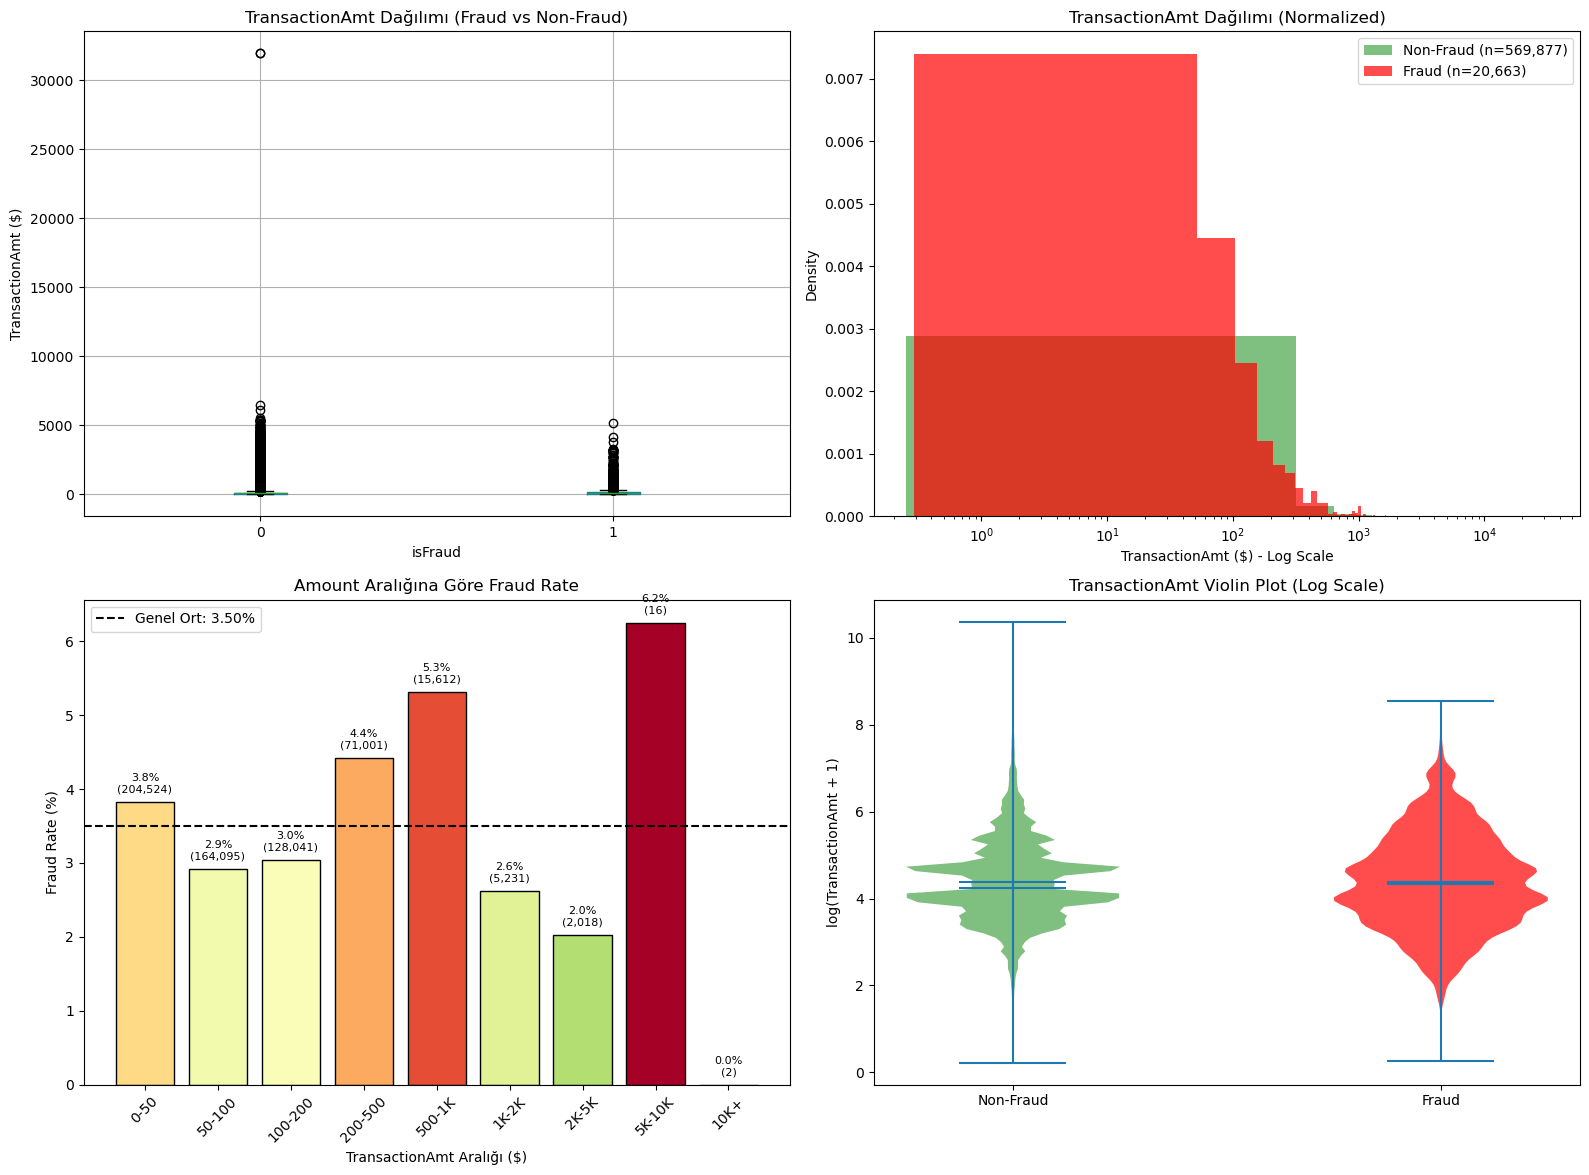

📊 TransactionAmt vs isFraud İSTATİSTİKLERİ

Metrik                          Non-Fraud           Fraud            Fark
----------------------------------------------------------------------
Ortalama                  $        134.51 $        149.24 $         14.73
Medyan                    $         68.50 $         75.00 $          6.50
Std Sapma                 $        239.40 $        232.21
Min                       $          0.25 $          0.29
Max                       $     31,937.39 $      5,191.00
%25 (Q1)                  $         43.97 $         35.04
%75 (Q3)                  $        120.00 $        161.00

📈 Mann-Whitney U Test:
   U-statistic: 5,858,540,820
   p-value: 2.26e-01
   Sonuç: Anlamlı fark yok

⚠️ EN RİSKLİ AMOUNT ARALIKLARI:
   1. $5K-10K: 6.25% fraud rate (16 işlem)
   2. $500-1K: 5.31% fraud rate (15,612 işlem)
   3. $200-500: 4.42% fraud rate (71,001 işlem)


In [25]:
# =============================================================================
# TransactionAmt vs isFraud Dağılımı
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Boxplot - Fraud vs Non-Fraud
ax1 = axes[0, 0]
df.boxplot(column='TransactionAmt', by='isFraud', ax=ax1)
ax1.set_title('TransactionAmt Dağılımı (Fraud vs Non-Fraud)')
ax1.set_xlabel('isFraud')
ax1.set_ylabel('TransactionAmt ($)')
plt.suptitle('')

# 2. Log-scale Histogram karşılaştırma
ax2 = axes[0, 1]
fraud_amt = df[df['isFraud'] == 1]['TransactionAmt']
non_fraud_amt = df[df['isFraud'] == 0]['TransactionAmt']

ax2.hist(non_fraud_amt, bins=100, alpha=0.5, label=f'Non-Fraud (n={len(non_fraud_amt):,})', 
         color='green', density=True)
ax2.hist(fraud_amt, bins=100, alpha=0.7, label=f'Fraud (n={len(fraud_amt):,})', 
         color='red', density=True)
ax2.set_xscale('log')
ax2.set_xlabel('TransactionAmt ($) - Log Scale')
ax2.set_ylabel('Density')
ax2.set_title('TransactionAmt Dağılımı (Normalized)')
ax2.legend()

# 3. Amount aralıklarına göre fraud rate
ax3 = axes[1, 0]
bins = [0, 50, 100, 200, 500, 1000, 2000, 5000, 10000, df['TransactionAmt'].max()]
labels = ['0-50', '50-100', '100-200', '200-500', '500-1K', '1K-2K', '2K-5K', '5K-10K', '10K+']
df['amt_bin'] = pd.cut(df['TransactionAmt'], bins=bins, labels=labels)

fraud_by_bin = df.groupby('amt_bin')['isFraud'].agg(['mean', 'count'])
fraud_by_bin['mean'] = fraud_by_bin['mean'] * 100

colors = plt.cm.RdYlGn_r(fraud_by_bin['mean'] / fraud_by_bin['mean'].max())
bars = ax3.bar(range(len(fraud_by_bin)), fraud_by_bin['mean'], color=colors, edgecolor='black')
ax3.set_xticks(range(len(fraud_by_bin)))
ax3.set_xticklabels(labels, rotation=45)
ax3.set_xlabel('TransactionAmt Aralığı ($)')
ax3.set_ylabel('Fraud Rate (%)')
ax3.set_title('Amount Aralığına Göre Fraud Rate')
ax3.axhline(y=df['isFraud'].mean()*100, color='black', linestyle='--', label=f"Genel Ort: {df['isFraud'].mean()*100:.2f}%")
ax3.legend()

for bar, (idx, row) in zip(bars, fraud_by_bin.iterrows()):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f'{row["mean"]:.1f}%\n({int(row["count"]):,})', ha='center', va='bottom', fontsize=8)

# 4. Violin Plot
ax4 = axes[1, 1]
# Log transform for better visualization
df['log_amt'] = np.log1p(df['TransactionAmt'])
parts = ax4.violinplot([df[df['isFraud']==0]['log_amt'].values, 
                        df[df['isFraud']==1]['log_amt'].values],
                       positions=[0, 1], showmeans=True, showmedians=True)

parts['bodies'][0].set_facecolor('green')
parts['bodies'][0].set_alpha(0.5)
parts['bodies'][1].set_facecolor('red')
parts['bodies'][1].set_alpha(0.7)

ax4.set_xticks([0, 1])
ax4.set_xticklabels(['Non-Fraud', 'Fraud'])
ax4.set_ylabel('log(TransactionAmt + 1)')
ax4.set_title('TransactionAmt Violin Plot (Log Scale)')

plt.tight_layout()
plt.show()

# İstatistiksel Özet
print("="*80)
print("📊 TransactionAmt vs isFraud İSTATİSTİKLERİ")
print("="*80)

print(f"\n{'Metrik':<25} {'Non-Fraud':>15} {'Fraud':>15} {'Fark':>15}")
print("-"*70)
print(f"{'Ortalama':<25} ${non_fraud_amt.mean():>14,.2f} ${fraud_amt.mean():>14,.2f} ${fraud_amt.mean()-non_fraud_amt.mean():>14,.2f}")
print(f"{'Medyan':<25} ${non_fraud_amt.median():>14,.2f} ${fraud_amt.median():>14,.2f} ${fraud_amt.median()-non_fraud_amt.median():>14,.2f}")
print(f"{'Std Sapma':<25} ${non_fraud_amt.std():>14,.2f} ${fraud_amt.std():>14,.2f}")
print(f"{'Min':<25} ${non_fraud_amt.min():>14,.2f} ${fraud_amt.min():>14,.2f}")
print(f"{'Max':<25} ${non_fraud_amt.max():>14,.2f} ${fraud_amt.max():>14,.2f}")
print(f"{'%25 (Q1)':<25} ${non_fraud_amt.quantile(0.25):>14,.2f} ${fraud_amt.quantile(0.25):>14,.2f}")
print(f"{'%75 (Q3)':<25} ${non_fraud_amt.quantile(0.75):>14,.2f} ${fraud_amt.quantile(0.75):>14,.2f}")

# Mann-Whitney U test
from scipy.stats import mannwhitneyu
stat, p_value = mannwhitneyu(fraud_amt, non_fraud_amt, alternative='two-sided')
print(f"\n📈 Mann-Whitney U Test:")
print(f"   U-statistic: {stat:,.0f}")
print(f"   p-value: {p_value:.2e}")
print(f"   Sonuç: {'İstatistiksel olarak ANLAMLI fark var' if p_value < 0.05 else 'Anlamlı fark yok'}")

# En riskli aralıklar
print("\n⚠️ EN RİSKLİ AMOUNT ARALIKLARI:")
risky = fraud_by_bin.sort_values('mean', ascending=False).head(3)
for i, (idx, row) in enumerate(risky.iterrows(), 1):
    print(f"   {i}. ${idx}: {row['mean']:.2f}% fraud rate ({int(row['count']):,} işlem)")

# Temizlik
df.drop(['amt_bin', 'log_amt'], axis=1, inplace=True)
print("="*80)

## 13. Fraud vs Non-Fraud TransactionAmt Histogram Dağılımı (Detaylı)

In [ ]:
# =============================================================================
# FRAUD vs NON-FRAUD TransactionAmt HISTOGRAM DAĞILIMI
# Hangi harcama değerlerinde daha çok fraud var?
# =============================================================================

fraud_amt = df[df['isFraud'] == 1]['TransactionAmt']
non_fraud_amt = df[df['isFraud'] == 0]['TransactionAmt']

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. Üst üste histogram (Linear Scale) - Düşük değerler
ax1 = axes[0, 0]
max_val = 500  # 500$ altı işlemlere odaklan
ax1.hist(non_fraud_amt[non_fraud_amt <= max_val], bins=50, alpha=0.6, 
         color='#2ecc71', label=f'Non-Fraud', density=True)
ax1.hist(fraud_amt[fraud_amt <= max_val], bins=50, alpha=0.7, 
         color='#e74c3c', label=f'Fraud', density=True)
ax1.set_xlabel('TransactionAmt ($)')
ax1.set_ylabel('Density')
ax1.set_title(f'Histogram: $0 - ${max_val}\n(İşlemlerin çoğunluğu)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Log-scale histogram (Tüm veri)
ax2 = axes[0, 1]
bins_log = np.logspace(np.log10(0.5), np.log10(df['TransactionAmt'].max()), 60)
ax2.hist(non_fraud_amt, bins=bins_log, alpha=0.6, color='#2ecc71', label='Non-Fraud', density=True)
ax2.hist(fraud_amt, bins=bins_log, alpha=0.7, color='#e74c3c', label='Fraud', density=True)
ax2.set_xscale('log')
ax2.set_xlabel('TransactionAmt ($) - Log Scale')
ax2.set_ylabel('Density')
ax2.set_title('Histogram (Log Scale)\nTüm veri')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Fraud Rate by Amount Bins (Detaylı)
ax3 = axes[0, 2]
bins_detailed = [0, 25, 50, 75, 100, 150, 200, 300, 500, 750, 1000, 2000, 5000, 10000, float('inf')]
labels_detailed = ['0-25', '25-50', '50-75', '75-100', '100-150', '150-200', 
                   '200-300', '300-500', '500-750', '750-1K', '1K-2K', '2K-5K', '5K-10K', '10K+']

df['amt_bin_detail'] = pd.cut(df['TransactionAmt'], bins=bins_detailed, labels=labels_detailed)
fraud_by_bin_detail = df.groupby('amt_bin_detail')['isFraud'].agg(['mean', 'count', 'sum'])
fraud_by_bin_detail['mean'] = fraud_by_bin_detail['mean'] * 100

# Renk skalası (düşük fraud=yeşil, yüksek fraud=kırmızı)
norm_values = fraud_by_bin_detail['mean'] / fraud_by_bin_detail['mean'].max()
colors = plt.cm.RdYlGn_r(norm_values)

bars = ax3.bar(range(len(fraud_by_bin_detail)), fraud_by_bin_detail['mean'], color=colors, edgecolor='black')
ax3.set_xticks(range(len(fraud_by_bin_detail)))
ax3.set_xticklabels(labels_detailed, rotation=45, ha='right')
ax3.set_xlabel('TransactionAmt Aralığı ($)')
ax3.set_ylabel('Fraud Rate (%)')
ax3.set_title('🎯 Hangi Tutarlarda Fraud Daha Yoğun?\n(Renk: Yeşil=Düşük Risk, Kırmızı=Yüksek Risk)')
ax3.axhline(y=df['isFraud'].mean()*100, color='black', linestyle='--', 
            linewidth=2, label=f"Genel Ort: {df['isFraud'].mean()*100:.2f}%")
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Fraud Sayısı vs İşlem Sayısı (Dual Axis)
ax4 = axes[1, 0]
x_pos = range(len(fraud_by_bin_detail))
width = 0.35

bars1 = ax4.bar([x - width/2 for x in x_pos], fraud_by_bin_detail['count'], width, 
                label='Toplam İşlem', color='#3498db', alpha=0.7)
ax4.set_ylabel('Toplam İşlem Sayısı', color='#3498db')
ax4.tick_params(axis='y', labelcolor='#3498db')

ax4_twin = ax4.twinx()
bars2 = ax4_twin.bar([x + width/2 for x in x_pos], fraud_by_bin_detail['sum'], width, 
                      label='Fraud Sayısı', color='#e74c3c', alpha=0.7)
ax4_twin.set_ylabel('Fraud Sayısı', color='#e74c3c')
ax4_twin.tick_params(axis='y', labelcolor='#e74c3c')

ax4.set_xticks(x_pos)
ax4.set_xticklabels(labels_detailed, rotation=45, ha='right')
ax4.set_xlabel('TransactionAmt Aralığı ($)')
ax4.set_title('İşlem Hacmi vs Fraud Sayısı\n(Mavi=Toplam, Kırmızı=Fraud)')
ax4.legend(loc='upper left')
ax4_twin.legend(loc='upper right')

# 5. KDE Karşılaştırması (Dağılım şekli)
ax5 = axes[1, 1]
from scipy import stats

# Log transform için
log_fraud = np.log1p(fraud_amt)
log_nonfraud = np.log1p(non_fraud_amt)

x_range = np.linspace(0, 10, 500)
fraud_kde = stats.gaussian_kde(log_fraud)
nonfraud_kde = stats.gaussian_kde(log_nonfraud)

ax5.fill_between(x_range, nonfraud_kde(x_range), alpha=0.5, color='#2ecc71', label='Non-Fraud')
ax5.fill_between(x_range, fraud_kde(x_range), alpha=0.5, color='#e74c3c', label='Fraud')
ax5.plot(x_range, nonfraud_kde(x_range), color='#27ae60', linewidth=2)
ax5.plot(x_range, fraud_kde(x_range), color='#c0392b', linewidth=2)

# X eksenini $ cinsinden etiketle
x_ticks = [0, np.log1p(10), np.log1p(50), np.log1p(100), np.log1p(500), np.log1p(2000), np.log1p(10000)]
ax5.set_xticks(x_ticks)
ax5.set_xticklabels(['$0', '$10', '$50', '$100', '$500', '$2K', '$10K'])
ax5.set_xlabel('TransactionAmt')
ax5.set_ylabel('Density')
ax5.set_title('KDE Dağılım Karşılaştırması\n(Fraud işlemler nerede yoğunlaşıyor?)')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. Fraud Yoğunluk Haritası (Heatmap style)
ax6 = axes[1, 2]

# Her bin için fraud oranını normalize et ve heatmap olarak göster
fraud_intensity = fraud_by_bin_detail['mean'].values.reshape(1, -1)
im = ax6.imshow(fraud_intensity, aspect='auto', cmap='RdYlGn_r')
ax6.set_xticks(range(len(labels_detailed)))
ax6.set_xticklabels(labels_detailed, rotation=45, ha='right')
ax6.set_yticks([])
ax6.set_title('🔥 Fraud Yoğunluk Haritası\n(Koyu Kırmızı = Yüksek Risk)')

# Her hücreye değer yaz
for i, (rate, count) in enumerate(zip(fraud_by_bin_detail['mean'], fraud_by_bin_detail['count'])):
    text_color = 'white' if rate > fraud_by_bin_detail['mean'].median() else 'black'
    ax6.text(i, 0, f'{rate:.1f}%\n({int(count):,})', ha='center', va='center', 
             fontsize=8, color=text_color, fontweight='bold')

plt.colorbar(im, ax=ax6, label='Fraud Rate (%)', orientation='horizontal', pad=0.15)

plt.tight_layout()
plt.show()

# =============================================================================
# DETAYLI TABLO
# =============================================================================
print("="*100)
print("📊 FRAUD vs NON-FRAUD TransactionAmt DAĞILIMI - DETAYLI ANALİZ")
print("="*100)

print(f"\n{'Aralık ($)':<15} {'Toplam':>12} {'Fraud':>10} {'NonFraud':>12} {'FraudRate':>12} {'Risk':>15}")
print("-"*80)

overall_fraud_rate = df['isFraud'].mean() * 100
for idx, row in fraud_by_bin_detail.iterrows():
    fraud_count = int(row['sum'])
    total_count = int(row['count'])
    non_fraud_count = total_count - fraud_count
    fraud_rate = row['mean']
    
    # Risk seviyesi
    if fraud_rate > overall_fraud_rate * 2:
        risk = "🔴 ÇOK YÜKSEK"
    elif fraud_rate > overall_fraud_rate * 1.5:
        risk = "🟠 YÜKSEK"
    elif fraud_rate > overall_fraud_rate:
        risk = "🟡 ORTA"
    else:
        risk = "🟢 DÜŞÜK"
    
    print(f"{idx:<15} {total_count:>12,} {fraud_count:>10,} {non_fraud_count:>12,} {fraud_rate:>11.2f}% {risk:>15}")

# En riskli ve en güvenli aralıklar
print("\n" + "="*100)
print("⚠️ EN RİSKLİ HARCAMA ARALIKLARI (Fraud Rate Sıralaması):")
top_risky = fraud_by_bin_detail.sort_values('mean', ascending=False).head(5)
for i, (idx, row) in enumerate(top_risky.iterrows(), 1):
    print(f"   {i}. ${idx}: {row['mean']:.2f}% fraud rate ({int(row['sum']):,} fraud / {int(row['count']):,} işlem)")

print("\n✅ EN GÜVENLİ HARCAMA ARALIKLARI:")
top_safe = fraud_by_bin_detail.sort_values('mean', ascending=True).head(5)
for i, (idx, row) in enumerate(top_safe.iterrows(), 1):
    print(f"   {i}. ${idx}: {row['mean']:.2f}% fraud rate ({int(row['sum']):,} fraud / {int(row['count']):,} işlem)")

# Özet istatistikler
print("\n" + "="*100)
print("📈 ÖZET İSTATİSTİKLER:")
print(f"   Genel Fraud Rate: {overall_fraud_rate:.2f}%")
print(f"   En Yüksek Fraud Rate: ${top_risky.index[0]} → {top_risky.iloc[0]['mean']:.2f}%")
print(f"   En Düşük Fraud Rate: ${top_safe.index[0]} → {top_safe.iloc[0]['mean']:.2f}%")
print(f"   Risk Farkı: {top_risky.iloc[0]['mean'] / top_safe.iloc[0]['mean']:.1f}x")

# Temizlik
df.drop(['amt_bin_detail'], axis=1, inplace=True)
print("="*100)